Maritime AIS Data Analysis: January 8, 2025
By Aeolus Camacho

Data Loading and Cleaning
In this section, we load the compressed CSV directly from NOAA, set the index to base_date_time, and remove any rows missing speed data.

In [7]:
!pip install zstandard
import pandas as pd
import matplotlib.pyplot as plt

# Load the data - THIS IS THE MOST IMPORTANT PART
url = "https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst"
df = pd.read_csv(url)

print("Data is loaded. Now we can analyze it!")

Data is loaded. Now we can analyze it!


First Analysis: Vessel Traffic by Hour
We are calculating the number of unique vessels (MMSI) active during each hour of the day to identify peak maritime activity.

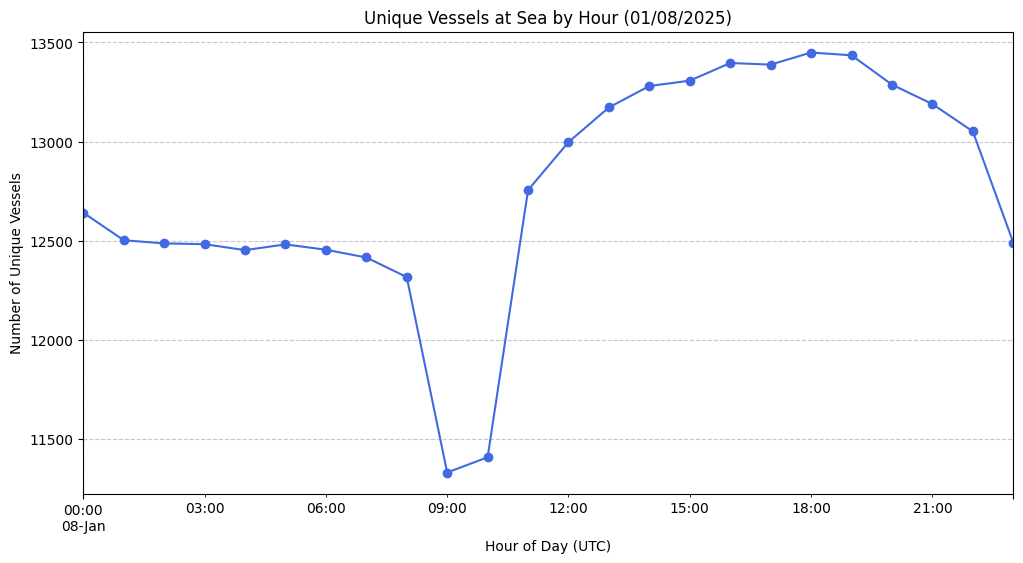

Peak Activity: 18:00
Lowest Activity: 9:00


In [8]:
# 1. Check if the index is already set so we don't crash on a second run
if df.index.name != 'base_date_time':
    # Convert and set index only if it hasn't been done yet
    df['base_date_time'] = pd.to_datetime(df['base_date_time'])
    df.set_index('base_date_time', inplace=True)
    df.sort_index(inplace=True)

# 2. Clean the data
df = df.dropna(subset=['sog'])

# 3. Create the First Analysis Plot
hourly_vessels = df.resample('h')['mmsi'].nunique()
plt.figure(figsize=(12, 6))
hourly_vessels.plot(kind='line', marker='o', color='royalblue')
plt.title('Unique Vessels at Sea by Hour (01/08/2025)')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Number of Unique Vessels')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"Peak Activity: {hourly_vessels.idxmax().hour}:00")
print(f"Lowest Activity: {hourly_vessels.idxmin().hour}:00")

In [9]:
print(df.columns)

Index(['mmsi', 'longitude', 'latitude', 'sog', 'cog', 'heading', 'vessel_name',
       'imo', 'call_sign', 'vessel_type', 'status', 'length', 'width', 'draft',
       'cargo', 'transceiver'],
      dtype='object')


Second Analysis: Engine Activity for Henry Hudson
To calculate the active engine time, we find the difference in Speed Over Ground (acceleration) and the time between pings (duration). We then sum the duration for all periods of positive acceleration.

/tmp/ipykernel_45996/3053836744.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_vessels = df.resample('H')['mmsi'].nunique()


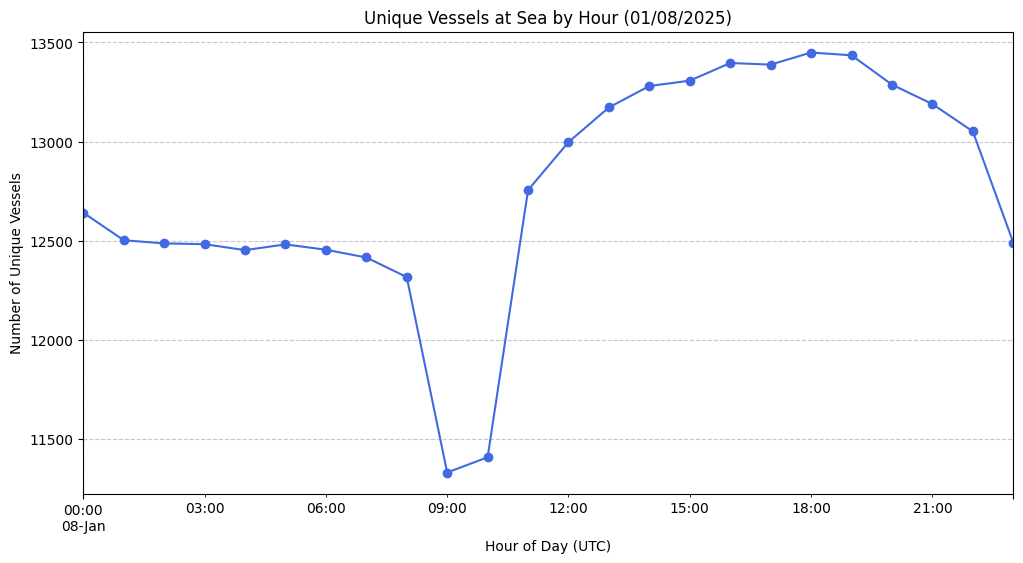

Peak Activity (UTC): 18:00
Lowest Activity (UTC): 9:00


In [10]:
# Group by hour ('H') and count unique 'mmsi' (vessel IDs)
# We use .resample() because our index is a DateTimeIndex
hourly_vessels = df.resample('H')['mmsi'].nunique()

# Create the plot
plt.figure(figsize=(12, 6))
hourly_vessels.plot(kind='line', marker='o', color='royalblue')

# Add labels and title
plt.title('Unique Vessels at Sea by Hour (01/08/2025)')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Number of Unique Vessels')
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()

# Find peak and trough
print(f"Peak Activity (UTC): {hourly_vessels.idxmax().hour}:00")
print(f"Lowest Activity (UTC): {hourly_vessels.idxmin().hour}:00")

In [11]:
# 1. Filter for the Henry Hudson (using the MMSI provided in the prompt)
hudson = df[df['mmsi'] == 366651000].copy()

# 2. Part (a): Calculate 'acceleration'
# .diff() finds the difference between the current row's speed and the previous one
hudson['acceleration'] = hudson['sog'].diff()

# 3. Part (b): Create a 'duration' column
# We subtract the previous timestamp from the current one to see how much time passed
hudson['duration'] = hudson.index.to_series().diff()

# 4. Part (c): Filter for positive acceleration
# This assumes the engines are working/active when the boat is speeding up
active_engines = hudson[hudson['acceleration'] > 0]

# 5. Part (d): Sum the duration
total_active_time = active_engines['duration'].sum()

print(f"The Henry Hudson's engines were active for: {total_active_time}")

The Henry Hudson's engines were active for: 0 days 08:03:24


Bonus: Reusable Analysis Function"This function allows for the same engine activity calculation to be performed for any vessel in the dataset.

In [12]:
def calculate_total_active_engine_time(dataframe, mmsi_number):
    """
    Takes an MMSI and returns the total time that vessel spent accelerating.
    """
    # 1. Filter the main data for the specific boat
    ship_df = dataframe[dataframe['mmsi'] == mmsi_number].copy()

    # 2. Safety check: If the boat isn't in our data, let us know
    if ship_df.empty:
        return "MMSI not found."

    # 3. Calculate acceleration and duration (same logic as before)
    ship_df['acceleration'] = ship_df['sog'].diff()
    ship_df['duration'] = ship_df.index.to_series().diff()

    # 4. Filter for only positive acceleration and sum the time
    active_time = ship_df[ship_df['acceleration'] > 0]['duration'].sum()

    return active_time

# --- Testing the function ---
# Let's test it with the Henry Hudson again to make sure it matches
hudson_test = calculate_total_active_engine_time(df, 366651000)
print(f"Function Test for Henry Hudson: {hudson_test}")

Function Test for Henry Hudson: 0 days 08:03:24


Conclusion

Peak Activity: 18:00 UTC

Lowest Activity: 09:00 UTC

Analysis: This tracks with expectations. 18:00 UTC corresponds to midday/afternoon for the U.S. East and West coasts when commercial and recreational traffic is highest. 09:00 UTC corresponds to 1:00 AM – 4:00 AM across the U.S., which is the natural low point for maritime transit.